# Trabalho de Conclusão de Curso - Universidade de Brasília

**Estudo:** Estruturação de Especificações BDD para Automação de Testes de Sistemas com IA: Um Estudo Observacional sobre a Detecção Autônoma de Elementos de Interface Gráfica

**Autores:** Gustavo França Boa Sorte e Leandro de Almeida Oliveira

**Orientador:** Prof. Msc. Hilmer Rodrigues Neri

**Caso:** CAPJu (Controle e Acompanhamento de Processos da Justiça), TRF 1ª Região

---

## Escopo

Este notebook documenta, com evidências reais extraídas dos artefatos do estudo (planilhas de acompanhamento e system prompts), o **passo a passo da Execução do Estudo de Caso** e a **Análise de Dados** da Questão Específica 1 (QE-1), cobrindo:

1. Adaptação da ferramenta (fork do Cypress Copilot, Nettur et al., 2025)
2. Calibração do *system prompt* em 4 tabelas/execuções sucessivas
3. Levantamento das Histórias de Usuário (USs) e Unidades de Análise
4. Execução dos Cenários BDD
5. Obstáculos e registros observados durante a execução
6. Análise de Dados: resultados da QE-1, a partir da Tabela 4 (execução definitiva)
7. Resposta à Questão de Pesquisa Principal
8. Limitações e Trabalhos Futuros

In [1]:
import os
import re
import datetime
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_colwidth', 120)
plt.rcParams['font.size'] = 9

# Diretório base do projeto (pasta TCC, um nível acima de Notebooks/)
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR

# Duas fontes de dados sustentam todo o notebook:
# - PATH_DADOS: planilha unica com as 4 tabelas do experimento (Tabela 1 Rascunho, Tabela 2 Refinamento,
#   Tabela 3 Definitivo/Calibracao, Tabela 4 Execucao Final), coladas na mesma aba.
# - PATH_CONSOLIDADO: recorte da Tabela 3 ja processado (com a classificacao dos cenarios bloqueados
#   em bug real vs. criterio de aceite ambiguo), usado nas Etapas 3 e 4.
PATH_DADOS = os.path.join(BASE_DIR, 'dados_geracao_testes.xlsx')
PATH_CONSOLIDADO = os.path.join(BASE_DIR, 'dados_consolidados_calibracao.xlsx')

print('BASE_DIR:', BASE_DIR)
for p in [PATH_DADOS, PATH_CONSOLIDADO]:
    print(('OK ' if os.path.exists(p) else 'FALTA '), p)


def to_num(v):
    """Converte valores numéricos armazenados como float ou como texto (ex.: '100%') em float."""
    if v is None:
        return None
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).strip().replace('%', '').replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return None


def decode_us(v):
    """Recupera o identificador original da US, desfazendo a autoconversão de data do Excel
    (quando '6.1' foi digitado numa célula geral, o Excel converteu para a data 6 de janeiro)."""
    if isinstance(v, (datetime.datetime, datetime.date)):
        return f"{v.day}.{v.month}"
    if isinstance(v, float):
        return str(int(v)) if v == int(v) else str(v)
    return str(v).strip()


def us_sort_key(us):
    parts = str(us).split('.')
    base = float(parts[0])
    sub = float(parts[1]) if len(parts) > 1 else 0.0
    return (base, sub)

BASE_DIR: C:\Users\Gustavo Sorte\Desktop\TCC
OK  C:\Users\Gustavo Sorte\Desktop\TCC\dados_geracao_testes.xlsx
OK  C:\Users\Gustavo Sorte\Desktop\TCC\dados_consolidados_calibracao.xlsx


---

## 1 - Adaptação da Ferramenta

O ponto de partida da execução foi um **fork da extensão Cypress Copilot** (NETTUR et al., 2025), extensão de código aberto para Visual Studio Code que gera código Cypress (Step Definitions + Page Object Model) a partir de cenários BDD, usando a API da OpenAI.

A ferramenta original foi modificada pelos autores em três frentes, para atender às necessidades específicas desta pesquisa:

1. **Reconhecimento de seletores/IDs explícitos dentro do próprio texto do BDD**: quando o cenário indica um elemento entre parênteses (ex.: `fills the CPF field(input[name="cpf"])`), a extensão original não tratava essa convenção. A adaptação ensina a IA a extrair esse seletor e usá-lo diretamente no código gerado, em vez de tentar adivinhar o elemento a partir do texto livre.

2. **Extração automática das métricas de completude (M1–M4 de Nettur et al., 2025)**: contagem de métodos de Step Definition e de Page Object Model gerados, e quantos ficaram sem implementação.

3. **Exibição das métricas na interface**: logo após a geração do POM e dos Métodos de Passo, para acompanhamento em tempo real durante a execução.

**Motivação (lacunas identificadas na revisão da literatura):** a ferramenta original de Nettur et al. (2025) não trata a identificação de elementos de interface a partir do BDD, nem foi validada em um estudo de caso real, apenas em um dataset sintético de ~55 histórias de usuário.

Também foi utilizada a **API da OpenAI (modelo GPT-4o)** para a geração do código, mantendo o mesmo modelo em toda a execução. A escolha não foi arbitrária: segundo Nettur et al. (2025), o GPT-4o foi o modelo com melhor desempenho na geração de código de automação Cypress, entre os avaliados pelos autores (GPT-4-Turbo, GPT-4o e GitHub Copilot).

---

## 2 - Calibração do *System Prompt*

O *system prompt* (o conjunto de regras que instrui a IA sobre como transformar um passo do BDD em código Cypress) não nasceu pronto. Ele foi construído e validado ao longo de **4 tabelas/execuções sucessivas**, todas registradas na mesma planilha (`dados_geracao_testes.xlsx`), uma após a outra na mesma aba.

1. **Tabela 1 (Rascunho) - Exploração**: o objetivo era explorar o CAPJu para entender os desafios de adaptar o *system prompt* à ferramenta. A forma encontrada foi escrever regras, algumas acompanhadas de exemplos, mas ainda sem padronização: as regras foram sendo criadas conforme a necessidade, US a US, ao mesmo tempo em que se buscava a forma correta de coletar os IDs dos elementos.

2. **Tabela 2 (Refinamento) - Primeira tentativa de padronização**: o objetivo era consolidar as regras aprendidas em um prompt único. Essa tentativa esbarrou em um caso específico, a **US18**, no qual não foi possível fazer o Cypress Copilot entender que deveria validar exatamente o texto passado no cenário BDD. Como solução paliativa, o texto exato a ser validado foi deixado escrito diretamente no *system prompt* daquela tentativa, apenas para viabilizar esse caso pontual e verificar se os demais cenários funcionariam com um prompt mais único, já que, àquela altura, o problema parecia praticamente impossível de resolver de outra forma.

3. **Tabela 3 (Definitivo) - Refinamento final do prompt**: o *system prompt* foi refinado até que o problema de validação de texto (da US18) fosse resolvido de forma genérica, diretamente pelo prompt, sem mais precisar fixar manualmente o texto esperado. A escrita dos próprios cenários BDD também foi ajustada nesta etapa.

4. **Tabela 4 (Execução Final)**: nesta última tabela já se dispunha de um *system prompt* considerado definitivo e funcional. Restava apenas rodar os testes, ajustando e refinando os cenários BDD até que cada um gerasse um teste automatizado que de fato funcionasse. Neste estudo, **"executar" ou "funcionar" significa que, a partir do BDD e daquele *system prompt*, o teste automatizado gerado rodava validando tudo o que o cenário BDD exigia**, ou seja, passava de ponta a ponta contra a aplicação real.

O modelo (GPT-4o) manteve-se o mesmo nas 4 tabelas. Vale destacar que a técnica de *prompting* empregada aqui difere da *few-shot chain* proposta por Nettur et al. (2025), que usa exemplos completos de entrada e saída, encadeados em duas chamadas. Neste estudo, optou-se por uma abordagem baseada em **regras explícitas de transformação**, algumas acompanhadas de um exemplo escrito de sintaxe, explicadas regra a regra mais adiante neste notebook.

A célula abaixo mede, diretamente nos dados da planilha, o tamanho (em caracteres) do *system prompt* usado em cada uma das 3 primeiras tabelas: evidência objetiva de que o prompt de fato evoluiu de "variável US a US" (Tabela 1) para "único e fixo" (Tabela 3).

In [2]:
# Carrega a planilha unica de dados e isola as 3 primeiras tabelas (fase de calibracao)
wb_hist = openpyxl.load_workbook(PATH_DADOS, data_only=True)
ws_hist = wb_hist.worksheets[0]
rows_hist = list(ws_hist.iter_rows(min_row=1, values_only=True))

# As tabelas sao delimitadas por linhas de cabecalho repetidas ("US" no inicio das 3 primeiras,
# "Execution" no inicio da 4a). Aqui usamos so as 3 primeiras (calibracao do system prompt).
block_starts = [i for i, r in enumerate(rows_hist) if r[0] == 'US']
block_starts.append(next(i for i, r in enumerate(rows_hist) if r[0] == 'Execution'))

evolucao = []
for bi in range(len(block_starts) - 1):
    start, end = block_starts[bi] + 1, block_starts[bi + 1]
    tamanhos = []
    for r in rows_hist[start:end]:
        if r[0] is None:
            continue
        prompt = r[5]  # coluna "system prompt code"
        if isinstance(prompt, str) and prompt.strip():
            tamanhos.append(len(prompt))
    n_us_testadas = sum(1 for r in rows_hist[start:end] if r[0] is not None)
    evolucao.append({
        'Rodada': ['1 - Rascunho', '2 - Refinamento', '3 - Definitivo'][bi],
        'USs testadas': n_us_testadas,
        'Tamanho médio do prompt (chars)': round(sum(tamanhos) / len(tamanhos)) if tamanhos else None,
        'Tamanho mínimo': min(tamanhos) if tamanhos else None,
        'Tamanho máximo': max(tamanhos) if tamanhos else None,
        'Prompt idêntico p/ todas as USs?': 'Sim' if len(set(tamanhos)) == 1 else 'Não',
    })

df_evolucao_prompt = pd.DataFrame(evolucao)
df_evolucao_prompt

,Rodada,USs testadas,Tamanho médio do prompt (chars),Tamanho mínimo,Tamanho máximo,Prompt idêntico p/ todas as USs?
0,1 - Rascunho,27,4707,3625,5548,Não
1,2 - Refinamento,30,12000,11980,12036,Não
2,3 - Definitivo,37,11934,11934,11934,Sim


A tabela confirma o relato: na **Rodada 1** o prompt variava bastante entre USs (3.625 a 5.548 caracteres, crescendo à medida que novas regras eram adicionadas); na **Rodada 2** já havia um prompt bem maior e quase uniforme (~12.000 caracteres); na **Rodada 3** o prompt é **idêntico, byte a byte, para todas as USs testadas**.

O prompt final completo (11.931 caracteres) está registrado e é exibido abaixo, na íntegra, como artefato documentado do estudo.

#### Estrutura das planilhas de acompanhamento

As Tabelas 1, 2 e 3 (`dados_geracao_testes.xlsx`) compartilham as mesmas colunas:

- **US**: identificação da História de Usuário à qual o critério de aceite pertence
- **BDD Scenario**: o cenário no formato Dado/Quando/Então que descreve o critério de aceite a ser testado
- **Page Object Class Code**: o código da classe de Page Object gerado a partir do BDD scenario
- **Step Definition Code**: o código dos Step Definitions gerado a partir do BDD scenario
- **Feature**: o arquivo `.feature` correspondente ao cenário, no padrão Gherkin
- **System Prompt Code**: o *system prompt* utilizado naquela tentativa/versão para orientar a geração do código
- **T.M Gerados - Step Definitions / POM**: quantidade total de métodos gerados em cada artefato (M1 e M3)
- **Métodos com/sem Implementação - Step Definition / POM**: quantos desses métodos vieram com implementação completa, e quantos ficaram vazios/pendentes
- **Fração com/sem Implementação - Step Definition / POM**: a mesma contagem anterior, expressa em proporção sobre o total gerado
- **Iterações**: número de tentativas/rodadas necessárias até se obter um resultado satisfatório (ou até o encerramento da análise daquele item)
- **Observações**: anotações livres sobre particularidades, dificuldades ou pontos de atenção identificados durante a execução daquele cenário

A **Tabela 4** (mesmo arquivo `dados_geracao_testes.xlsx`, colada logo abaixo da Tabela 3) usa essas mesmas colunas, com duas diferenças: acrescenta, no início, a coluna **Execution** (identificando a execução/tentativa à qual aquela linha se refere), e **não possui mais a coluna Iterações**. Essa troca reflete uma mudança de foco: nesta etapa, o system prompt já estava definitivo, então o trabalho passou a se concentrar apenas em ajustar o BDD de entrada e verificar se o código gerado rodava ponta a ponta no Cypress. Por isso, cada linha já é, em si, uma tentativa individual (o que antes seria resumido em um número de "Iterações" passa a estar registrado tentativa a tentativa, cada uma com seu próprio resultado, identificada pela coluna de execução).

### System prompt final:

"""
You are an expert Cypress Test Automation Engineer following Cypress best practices. Generate step definitions and Page Objects using `@badeball/cypress-cucumber-preprocessor`, following these rules:  0. **ABSOLUTE PRIORITY — never invent selectors** — Whenever the BDD step provides an explicit selector, in parentheses `(selector)` or in `[text: ...]`/bracket notation, that exact selector is the ONLY source of truth and overrides every other rule, heuristic, or assumption (including rules 2 and 3 below). NEVER substitute it with `cy.contains(...)`, a guessed class name, or any selector not present in the BDD step. NEVER fabricate a selector (e.g. `.process-table`) that does not appear anywhere in the BDD text — if no selector is given, use `cy.contains('button', 'text')` per rule 2, but if one IS given, you must use it verbatim in `cy.get()`. WORKED EXAMPLE OF A COMMON MISTAKE TO AVOID: given the BDD step `click the Save button(button[data-index=\"2\"])`, it is WRONG to write `cy.contains('button', 'Save')` just because the button also has visible text — the parenthetical selector is present, so rule 2 does NOT apply here. The ONLY correct output is `cy.get('button[data-index=\"2\"]')`. Apply this same check to every single element method you write: before writing `cy.contains(...)`, re-scan that exact BDD line for a `(...)` selector; if you find one, you must use `cy.get()` with it instead, with no exceptions. The presence of visible button/link text in the BDD step is irrelevant once a parenthetical selector exists on that line.  1. **Selectors in parentheses — strip from the step string, but re-attach as an inline comment** — If a BDD step has a selector in parentheses, e.g. `fills the Email field(input[name=\"email\"])`, you MUST strip the parenthetical `(...)` AND any trailing `[text: ...]` or `[N]` bracket notation from the step definition string used in `Given`/`When`/`Then`. The step string passed to Given/When/Then/cucumber must contain ONLY plain text and `{string}` placeholders — it must never contain literal `(`, `)`, `[`, or `]` characters copied from the BDD source. BUT this stripped information must NOT be discarded — you MUST re-attach it as a single-line comment immediately after the opening `{` of that step's callback, in the exact format `// bdd: <selector>` (plain selector), `// bdd: <selector>[N]` (explicit index), or `// bdd: <selector>[text: <verbatim text, copied character-for-character, however long>]` (verbatim assertion text). This comment is the ONLY place this information survives into the {step} file, and the {step} file is the ONLY input the next generation step ({page}) receives — an omitted or altered comment means that information is permanently lost for Page Object generation. Example: `enter Email {string} (input[name=\"email\"])` becomes `When(\"enter Email {string}\", (email) => { // bdd: input[name=\\\"email\\\"]\\n  SomePage.enterEmail(email);\\n});`. Another example: `click the Save button(button[data-index=\"2\"])[0]` becomes `Given(\"click the Save button\", () => { // bdd: button[data-index=\\\"2\\\"][0]\\n  SomePage.clickSave();\\n});`. This applies to every method that touches that element, including click, type, and assertion methods — never fall back to `cy.contains()` once an explicit selector exists.  2. **Buttons by text only** — If, and only if, a button is referenced only by visible text with NO parenthetical selector anywhere in that step, use `cy.contains('button', 'text').click()`.  3. **Tab buttons** — For clicking a tab, always use `cy.contains('button[role=\"tab\"]', 'text').click()` — never plain `cy.contains('button', 'text')`, which can match the wrong element.  4. **Given/When/Then only** — Never import or use `And`/`But` (not exported by `@badeball/cypress-cucumber-preprocessor`). Map each `And` to the block it follows: after Given → Given, after When → When, after Then → Then.  5. **Relative imports** — Always import Page Objects with relative paths from the steps folder, e.g. `'../pages/LoginPage'`. Never use aliases like `@pages/LoginPage`.  6. **File name = class name** — The Page Object file name must exactly match its class name. Class `AdicionarObservacaoPage` → file `AdicionarObservacaoPage.js`, imported as `'../pages/AdicionarObservacaoPage'`.  7. **Static class, named export** — Declare `export class ClassName { static method() {...} }`. Step files import the named export — `import { ClassName } from '../pages/ClassName'` — and call `ClassName.method()`.  8. **Timeout goes on `cy.get()` only** — Custom timeouts belong on `cy.get()`, never on `.click()` or `.should()`. Correct: `cy.get('selector', { timeout: 10000 }).should('be.visible').click()`. Wrong: putting `{ timeout: 10000 }` on `.click()`.  9. **Intercept before the triggering action** — `cy.intercept().as('alias')` must always run before the action that fires the request. A setup → click → wait sequence in the BDD becomes three separate Page Object methods: one for the intercept, one for the click, one for `cy.wait('@alias')`.  10. **Explicit waits stay isolated** — `'aguarda/waits N ms'` → `cy.wait(N)`, either inline in the step or in its own dedicated method. Never embed `cy.wait()` inside a method that does something else.  11. **Assertions** — Text content: `cy.get('selector').should('contain', text)`. Visibility: `cy.get('selector').should('be.visible')`. Never chain `.contains(text)` before `.should('be.visible')` — it changes the assertion subject.  12. **Everything goes through the Page Object** — Every Given/When/Then step calls a Page Object static method; no raw `cy` commands inside step definitions. The only exceptions are `cy.visit()` in the first Given step and `cy.wait(ms)` for explicit wait steps. Generate one Page Object method per interaction or verification.  13. **Repeated selectors → `.eq(N)`** — When the same parenthetical content appears across multiple BDD steps, number occurrences `.eq(0)`, `.eq(1)`, `.eq(2)`... in order of appearance, using one running counter regardless of context. E.g. if `clicar na tab Detalhes(div[role=\"tablist\"] > button[data-index=\"0\"])` appears twice, the first instance gets `.eq(0)` and the second `.eq(1)` — even if they follow different accordions.  14. **Literal text unless quoted** — Unquoted BDD text (e.g. `deve aparecer o nome João Pedro Alves Costa`) is written as a literal string in the step definition, not `{string}`. Use `{string}` only when the BDD text itself is quoted (e.g. `deve aparecer o nome \"João\"`).  15. **`[text: ...]` is verbatim — copy the FULL text, never a summary** — Copy EVERY character between `[text: ` and the closing `]` into the .should('contain', ...) string, exactly as written, from the first character to the last, no matter how long the text is (a one-word label and a multi-sentence paragraph follow the exact same rule). NEVER replace it with your own paraphrase, summary, or shortened description of what the text is about (e.g. never write 'sobre Capju' or 'general information' when the source has a full paragraph — the FULL paragraph itself is the only correct output). NEVER truncate the string early with '...', '[...]', or any other ellipsis/placeholder. Keep any short label prefix that precedes the value (e.g. Nome:, Email:, Status:) exactly as written — it is part of the literal text. Since your output string is wrapped in single quotes ('...'), if the source text itself contains a double-quoted phrase (e.g. [text: sample stands for \"placeholder\". more filler text.]), that inner \"...\" is NOT the end of the bracket — only the final `]` ends it — so keep copying everything past it with no backslash-escaping needed: cy.get(selector).should('contain', 'sample stands for \"placeholder\". more filler text.'). Before finalizing your answer, count the sentences in the source [text: ...] block and confirm your .should('contain', ...) string contains that exact same number of sentences, word for word — if it has fewer, you truncated or paraphrased and must go back and copy the rest.   When generating the {page} file from the {step} file, the `// bdd: <selector>[text: ...]` comment attached to each step (per rule 1) is the DEFINITIVE and ONLY source for the exact assertion text — the step's plain English description (e.g. \"the general information about Capju should appear\") is NEVER the source text and must never be used or paraphrased as the assertion; always copy the text from inside the `[text: ...]` portion of that comment instead.  16. **`[N]` is an explicit index** — A bracketed number after a selector, e.g. `clicks the button(#submit)[0]` or `verifies the row(.table-row)[2]`, is stripped from the step text and becomes `.eq(N)` on the `cy.get()` chain: `cy.get('#submit').eq(0).click()`, `cy.get('.table-row').eq(2)`.   When generating the {page} file from the {step} file, the `// bdd: <selector>[N]` comment attached to each step (per rule 1) is the DEFINITIVE source for both the selector and its index — read it and translate directly into `cy.get('<selector>').eq(N)`; never guess the index from context and never omit `.eq(N)` just because the step's plain-English text no longer shows brackets.  17. **Strict output scope per request** — `{step}` and `{page}` are two independent generation requests. For `{step}`: output only the step definition code (imports, Given/When/Then blocks, calls into Page Object methods) — no Page Object class, elements, or method bodies. For `{page}`: output only the Page Object class (its elements and methods) — no step definitions, no Given/When/Then, no `@badeball/cypress-cucumber-preprocessor` imports. Never combine both in one response, even partially, and never repeat content belonging to the other file.  18. **Class names must match across both files** — The Page Object class names imported and called in the {step} file must be EXACTLY the same class names, with the exact same methods, that are (or will be) defined in the {page} file. Never invent a class (e.g. `LoginPage`) in the step file's imports/calls unless that exact class, with that exact method, is also defined in the Page Object response. If a single feature only needs one Page Object class, put ALL the interaction and verification methods for every step of that scenario into that one class — do not split methods across a class that is referenced but never generated. Before finishing the {step} file, verify every `ClassName.method()` call has a corresponding class and method that exists in the {page} file.  19. **Mandatory self-check before responding** — Before you output the final {page} file, go back through the original BDD text line by line. For every line that contains a `(...)` selector, find the corresponding element method you wrote and confirm it uses `cy.get('<that exact selector>')`, NOT `cy.contains(...)` and NOT any other selector. For every line that contains `[text: ...]`, character-by-character compare the string you wrote inside `.should('contain', ...)` against the text between `[text:` and the closing `]` in the BDD — they must be byte-for-byte identical (same length, same punctuation, same accents, same label prefixes like `Nome:` — a prefix you dropped is a FAILED check just like a missing sentence); if your string contains `...` anywhere that isn't in the source, is shorter than the source, is missing a label prefix the source has, or is a paraphrase/summary/description instead of the source text — including one that sounds plausible because you recognize the subject from training — that is a FAILED check — go back and paste the complete original text, character-for-character from the BDD input itself (not from memory or general knowledge of the topic), before responding, no matter how many words or sentences it has. If any method fails either check, rewrite it before responding. Do this silently — do not show this checklist in the output, just apply the correction.
"""

### Explicação regra por regra

O *system prompt* definitivo (Tabela 3), exibido por completo acima, é composto por 20 regras (numeradas de 0 a 19), cada uma criada para corrigir ou prevenir um problema específico observado ao longo da calibração. As duas células abaixo documentam, regra a regra, **para que serve**, **por que foi criada** e, quando aplicável, um **exemplo** de aplicação.

#### Regras 0 a 9

**Regra 0 - Nunca inventar seletores**
- *Para que serve*: garante que, sempre que o BDD trouxer um seletor explícito entre parênteses ou em `[text: ...]`, esse seletor seja usado literalmente em `cy.get()`, sem substituição por `cy.contains()` ou por um seletor "adivinhado".
- *Por que foi criada*: corrige o erro mais crítico e mais comum de geração de testes com IA: o modelo "alucinar" um seletor plausível (baseado no nome do elemento) em vez de usar o seletor real da aplicação, erro que faz o teste falhar contra a interface real mesmo com código sintaticamente correto.
- *Exemplo*: para o BDD `click the Save button(button[data-index="2"])`, o correto é `cy.get('button[data-index="2"]')`; seria errado escrever `cy.contains('button', 'Save')`.

**Regra 1 - Seletor sai da string do step, mas vira comentário `// bdd:`**
- *Para que serve*: remove o seletor/índice/texto de asserção da string legível do Gherkin, deixando nela apenas texto plano e placeholders `{string}`, mas preserva essa informação como comentário no código, já que a geração seguinte (Page Object) só recebe o arquivo de steps como entrada.
- *Por que foi criada*: resolve um problema de "perda de informação entre etapas": como a geração acontece em duas chamadas separadas (Regra 17), sem esse comentário o seletor original se perderia entre a geração do step e a geração do Page Object.
- *Exemplo*: `enter Email {string} (input[name="email"])` vira `When("enter Email {string}", (email) => { // bdd: input[name="email"] ... })`.

**Regra 2 - Botões só por texto**
- *Para que serve*: define o comportamento padrão (`cy.contains('button', 'text')`) para quando NÃO existe seletor explícito no BDD.
- *Por que foi criada*: complementa a Regra 0, dando ao modelo uma opção válida para os casos em que realmente não há seletor fornecido, evitando que ele tente inventar um.

**Regra 3 - Botões de aba (tabs)**
- *Para que serve*: força o uso de `cy.contains('button[role="tab"]', 'text')` em vez de `cy.contains('button', 'text')` para elementos de aba.
- *Por que foi criada*: corrige um erro observado de ambiguidade de seletor. Em interfaces com abas, `cy.contains('button', 'text')` puro pode capturar um botão errado, com texto parecido em outro lugar da tela.

**Regra 4 - Apenas Given/When/Then**
- *Para que serve*: proíbe o uso de `And`/`But`, mandando mapear cada `And` para o bloco anterior (`Given`, `When` ou `Then`).
- *Por que foi criada*: corrige uma limitação técnica real da biblioteca `@badeball/cypress-cucumber-preprocessor`, que não exporta `And`/`But`. Sem essa regra, o código gerado quebraria por erro de import.

**Regra 5 - Imports relativos**
- *Para que serve*: obriga o uso de caminhos relativos (`'../pages/LoginPage'`) em vez de aliases (`@pages/LoginPage`).
- *Por que foi criada*: garante compatibilidade com a estrutura real do projeto, que não tem aliases configurados, evitando erro de "módulo não encontrado" na hora de rodar o teste.

**Regra 6 - Nome do arquivo = nome da classe**
- *Para que serve*: garante consistência entre o nome da classe declarada e o nome do arquivo/import correspondente.
- *Por que foi criada*: evita erro de import por descompasso de nome. Um dos tipos de erro descritos no artigo do Cypress Copilot é justamente "POM class file path not found".
- *Exemplo*: classe `AdicionarObservacaoPage` → arquivo `AdicionarObservacaoPage.js`, import `'../pages/AdicionarObservacaoPage'`.

**Regra 7 - Classe estática, exportação nomeada**
- *Para que serve*: define o padrão de código exato a ser usado (`export class ClassName { static method() {...} }`) e a forma de importar/chamar.
- *Por que foi criada*: padroniza a arquitetura do código gerado para que todos os Page Objects sigam a mesma convenção, facilitando manutenção e revisão.
- *Exemplo*: `import { ClassName } from '../pages/ClassName'` e depois `ClassName.method()`.

**Regra 8 - Timeout só em `cy.get()`**
- *Para que serve*: especifica onde a opção `{ timeout: N }` deve ficar na cadeia de comandos Cypress.
- *Por que foi criada*: corrige um erro comum de sintaxe do Cypress. Colocar timeout em `.click()` ou `.should()` não tem o efeito esperado e pode causar falhas silenciosas de teste.
- *Exemplo*: correto: `cy.get('selector', { timeout: 10000 }).should('be.visible').click()`; errado: timeout em `.click()`.

**Regra 9 - Intercept antes da ação que dispara a requisição**
- *Para que serve*: garante a ordem correta de comandos ao lidar com chamadas de rede (`cy.intercept()` deve vir antes da ação que a dispara).
- *Por que foi criada*: evita um erro clássico de teste assíncrono no Cypress. Se o intercept for configurado depois da ação, a requisição já pode ter sido feita e o intercept não capturará nada.

#### Regras 10 a 19

**Regra 10 - Esperas explícitas ficam isoladas**
- *Para que serve*: isola `cy.wait(N)` em seu próprio método ou linha, sem misturar com outra lógica.
- *Por que foi criada*: mantém a rastreabilidade entre o step BDD "aguarda N milissegundos" e o código gerado, evitando que uma espera fique escondida dentro de um método com outro propósito.

**Regra 11 - Asserções**
- *Para que serve*: define exatamente qual comando usar para cada tipo de verificação (conteúdo de texto vs. visibilidade), e proíbe encadear `.contains()` antes de `.should('be.visible')`.
- *Por que foi criada*: evita um erro sutil do Cypress em que encadear `.contains()` muda o "sujeito" da asserção seguinte, fazendo o teste verificar a coisa errada.
- *Exemplo*: `cy.get('selector').should('contain', text)` / `cy.get('selector').should('be.visible')`.

**Regra 12 - Tudo passa pelo Page Object**
- *Para que serve*: proíbe comandos Cypress "crus" dentro dos step definitions (com duas exceções: `cy.visit()` e `cy.wait()`), forçando toda interação a passar por um método do Page Object.
- *Por que foi criada*: é a regra central que garante a adoção do padrão Page Object Model (POM). Também é a regra mais diretamente ligada à saturação em 100% das métricas de completude (M1-M8), pois obriga a existência de um método para cada interação.

**Regra 13 - Seletores repetidos → `.eq(N)`**
- *Para que serve*: define como numerar elementos que compartilham o mesmo seletor entre múltiplos steps, usando um contador único crescente.
- *Por que foi criada*: evita ambiguidade quando a página tem múltiplos elementos com o mesmo seletor CSS. Sem indexação, `cy.get()` pegaria sempre o primeiro elemento encontrado, ignorando qual instância o BDD realmente queria.
- *Exemplo*: `clicar na tab Detalhes(div[role="tablist"] > button[data-index="0"])` aparecendo duas vezes: primeira ocorrência `.eq(0)`, segunda `.eq(1)`.

**Regra 14 - Texto literal, a menos que citado entre aspas**
- *Para que serve*: diferencia quando o texto do BDD deve virar um placeholder `{string}` (texto entre aspas) ou ficar fixo/literal na string do step (texto sem aspas).
- *Por que foi criada*: evita generalização indevida. Se todo texto virasse `{string}`, o step perderia precisão; a regra mantém o Gherkin fiel à intenção original de "valor variável" vs. "texto fixo esperado".
- *Exemplo*: `deve aparecer o nome João Pedro Alves Costa` → literal. `deve aparecer o nome "João"` → `{string}`.

**Regra 15 - `[text: ...]` é verbatim, nunca resumo**
- *Para que serve*: obriga a cópia caractere a caractere do texto entre `[text:` e `]` para dentro do `.should('contain', ...)`, proibindo paráfrase, resumo ou truncamento.
- *Por que foi criada*: é a regra mais extensa e mais reforçada do prompt (tem inclusive uma checagem de contagem de frases embutida), criada em resposta direta a um erro observado de o modelo "resumir" ou abreviar textos longos de asserção, fazendo o teste falhar por não encontrar o texto completo na tela real.
- *Exemplo*: se a fonte diz `sample stands for "placeholder". more filler text.`, a saída correta é `cy.get(selector).should('contain', 'sample stands for "placeholder". more filler text.')`, completo, sem resumir.

**Regra 16 - `[N]` é um índice explícito**
- *Para que serve*: define como converter um número entre colchetes após o seletor em `.eq(N)` na cadeia `cy.get()`.
- *Por que foi criada*: complementa a Regra 13, mas para os casos em que o índice já vem explícito no próprio BDD (em vez de precisar ser inferido pela ordem de aparição), reduzindo ambiguidade em cenários com elementos repetidos.
- *Exemplo*: `clicks the button(#submit)[0]` → `cy.get('#submit').eq(0).click()`.

**Regra 17 - Escopo de saída estrito por requisição**
- *Para que serve*: impede que o modelo misture o conteúdo do arquivo `{step}` com o do arquivo `{page}` numa mesma resposta.
- *Por que foi criada*: como a geração acontece em duas chamadas separadas à API, essa regra evita respostas "poluídas" com conteúdo do arquivo errado, o que quebraria o processo automatizado de extrair e salvar cada arquivo separadamente.

**Regra 18 - Nomes de classe devem coincidir entre os dois arquivos**
- *Para que serve*: garante que toda classe/método chamado no arquivo de steps realmente exista, com o mesmo nome, no arquivo de Page Object gerado.
- *Por que foi criada*: evita um erro de consistência entre as duas chamadas de geração (steps e POM são gerados separadamente). Sem essa regra, o modelo poderia "inventar" uma classe no arquivo de steps que nunca é de fato criada no Page Object.

**Regra 19 - Autoverificação obrigatória antes de responder**
- *Para que serve*: manda o modelo revisar seu próprio código gerado, linha por linha do BDD original, conferindo se cada seletor e cada texto de asserção batem exatamente com a fonte, antes de entregar a resposta final.
- *Por que foi criada*: é uma camada extra de segurança sobre as Regras 0 e 15, aparentemente adicionada depois de observar que, mesmo com as regras explícitas, o modelo ainda cometia esses erros; a autoverificação tenta fazer o próprio modelo "se policiar" antes de responder.

---

## Etapa 3 - Levantamento das Histórias de Usuário e Unidades de Análise

A cadeia de unidades de análise do estudo é:

> **História de Usuário (US) → Critérios de Aceitação (CAs) → Cenário BDD → Código de Teste Gerado**

As USs foram levantadas a partir das *issues* do projeto no GitHub, organizadas via ZenHub (repositório `fga-eps-mds/2023-1-CAPJu-Doc`). Cada issue segue o formato padrão "Eu como / desejo / para que", com uma lista de Critérios de Aceitação, onde cada uma delas deram origem a um Cenário BDD próprio (por isso algumas USs aparecem com sufixo decimal na planilha, ex.: `9.1`, `9.2`, `9.3`, `9.4`, um cenário para cada critério de aceitação da US 9).

A célula abaixo carrega a Tabela 3, já consolidada em `dados_consolidados_calibracao.xlsx` (mesma fonte usada na Etapa 4), e lista todas as USs levantadas.

In [3]:
# Carrega a Tabela 3 (mesma fonte da Etapa 4, ja consolidada em dados_consolidados_calibracao.xlsx)
wb_us = openpyxl.load_workbook(PATH_CONSOLIDADO, data_only=True)
ws_us = wb_us['Tabela3_Calibracao']

cols = [c.value for c in ws_us[1]]
data = [r for r in ws_us.iter_rows(min_row=2, values_only=True) if r[0] is not None]
df_us = pd.DataFrame(data, columns=cols)
df_us = df_us.iloc[df_us['US'].map(us_sort_key).argsort()].reset_index(drop=True)

uss_base = sorted(set(u.split('.')[0] for u in df_us['US']), key=lambda x: float(x))
uss_bug = df_us.loc[df_us['TipoBloqueio'] == 'BUG_APLICACAO', 'US'].tolist()
uss_ambiguo = df_us.loc[df_us['TipoBloqueio'].isin(['CRITERIO_AMBIGUO', 'MISTO_BUG_E_CRITERIO_AMBIGUO']), 'US'].tolist()

print(f'Total de linhas na planilha (USs + variantes de Critério de Aceitação): {len(df_us)}')
print(f'USs base únicas presentes na planilha de execução: {len(uss_base)} -> {uss_base}')
print(f'USs bloqueadas por bug real encontrado no CAPJu: {uss_bug}')
print(f'USs bloqueadas por critério de aceite ambíguo/não especificado: {uss_ambiguo}')
print(f'\nObservação: as 23 USs levantadas no planejamento (TCC1, seção 4.7) estão todas presentes nesta planilha de execução.')

df_us[['US', 'Bloqueado', 'TipoBloqueio']]

Total de linhas na planilha (USs + variantes de Critério de Aceitação): 37
USs base únicas presentes na planilha de execução: 23 -> ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '16', '18', '19', '25', '28', '34', '35', '36', '37', '38', '39', '40', '41']
USs bloqueadas por bug real encontrado no CAPJu: ['7', '28', '37', '39']
USs bloqueadas por critério de aceite ambíguo/não especificado: ['1', '1.1', '1.3', '19', '19.1', '19.2']

Observação: as 23 USs levantadas no planejamento (TCC1, seção 4.7) estão todas presentes nesta planilha de execução.


,US,Bloqueado,TipoBloqueio
0,1,True,MISTO_BUG_E_CRITERIO_AMBIGUO
1,1.1,True,CRITERIO_AMBIGUO
2,1.2,False,NaN
3,1.3,True,CRITERIO_AMBIGUO
4,1.4,False,NaN
5,2,False,NaN
6,2.1,False,NaN
7,3,False,NaN
8,4,False,NaN
9,5,False,NaN


### Exemplo: acompanhando uma única US do início ao fim

Para tornar a cadeia de unidades de análise **US → Critérios de Aceitação → Cenário BDD → Código de Teste Gerado**, vamos acompanhar passo a passo um único caso real: a **US41 ("Adicionar observação ao processo")**.

Escolhemos essa US como exemplo porque ela ilustra bem os desafios do processo: como veremos na Etapa 4 e na Seção 6, o cenário passou por ajustes de seletor e do próprio texto do BDD até chegar a um teste funcional.

A seguir, vamos examinar, um artefato por vez: (1) o cenário BDD escrito pelos autores, (2) o Page Object Model gerado pela ferramenta adaptada, e (3) as Step Definitions geradas, explicando o papel de cada um e como eles se conectam entre si.

In [4]:
exemplo_us = '41'
bdd_41 = pom_41 = step_41 = m1_41 = m3_41 = iters_41 = obs_41 = None

# A Tabela 3 fica entre o 3o cabecalho 'US' e o cabecalho 'Execution' (que abre a Tabela 4)
wb_v3_ex = openpyxl.load_workbook(PATH_DADOS, data_only=True)
ws_v3_ex = wb_v3_ex.worksheets[0]
rows_v3_ex = list(ws_v3_ex.iter_rows(min_row=1, values_only=True))
us_header_rows = [i for i, r in enumerate(rows_v3_ex) if r[0] == 'US']
tabela3_start = us_header_rows[2] + 1
tabela3_end = next(i for i, r in enumerate(rows_v3_ex) if r[0] == 'Execution')

for row in rows_v3_ex[tabela3_start:tabela3_end]:
    us = row[0]
    if us is not None and decode_us(us) == exemplo_us:
        bdd_41, pom_41, step_41 = row[1], row[2], row[3]
        m1_41, m3_41, iters_41, obs_41 = int(row[6]), int(row[7]), int(row[16]), row[17]
        break

print(f'Dados extraídos da Tabela 3 para a US {exemplo_us}:')
print(f'  Métodos de Passo gerados (M1): {m1_41}')
print(f'  Métodos POM gerados (M3): {m3_41}')

Dados extraídos da Tabela 3 para a US 41:
  Métodos de Passo gerados (M1): 13
  Métodos POM gerados (M3): 11


#### 1. O Cenário BDD como artefato de entrada

O cenário abaixo foi escrito pelos autores a partir da US41 e de seu Critério de Aceitação, seguindo a estrutura **Dado-Quando-Então** (*Given-When-Then*). Repare que vários passos trazem, entre parênteses, o seletor exato do elemento HTML envolvido, por exemplo, `(input[name="cpf"])` ou `(.react-flow__edgelabel-renderer .chakra-button)`.

Essa notação não é padrão do Gherkin, mas foi uma convenção adotada pelos próprios autores (Regra 0 do *system prompt*, exibida na Etapa 2) justamente para que a IA não precisasse "adivinhar" a qual elemento da tela cada passo se refere: o seletor já vem informado diretamente no texto do BDD, e a IA apenas o utiliza. **Quando o elemento não possuía um ID exato definido, utilizava-se o próprio seletor CSS como identificador do elemento, no lugar do ID.**

In [5]:
print(bdd_41)

Feature: Add Observation to Process

  Scenario: Authenticated user successfully adds an observation to a process
    Given the user accesses "http://localhost:3000"
    And fills in the CPF field(input[name="cpf"]) with "12345678909"
    And fills in the password field(input[name="password"]) with "123Testen"
    And clicks the Entrar button
    And waits for the Processos tab([id="tabs-:rf:--tab-3"]) to be visible
    And waits 1000 milliseconds
    And clicks the Processos tab
    And waits up to 10 seconds for the visualizar processo button(button[aria-label="Visualizar Processo"]) to be visible and clicks it
    When the user clicks the first Adicionar observação button(.react-flow__edgelabel-renderer .chakra-button)
    And fills in the observation field(textarea[name="comment"]) with "Observação de teste"
    And clicks the Salvar button
    Then the success notification([data-status="success"]) containing "Sua observação foi adicionada" is displayed
    And the observation prev

#### 2. O Page Object Model (POM) gerado

O **Page Object Model** é um padrão de projeto de automação de testes que reúne, numa única classe, todos os seletores e as interações possíveis com uma página (ou componente) da aplicação. Cada seletor indicado entre parênteses no BDD se torna, aqui, um método da classe, por exemplo, `fillCPFField`, `clickEntrarButton`, `clickAdicionarObservacaoButton`.

Esse é o artefato de onde vêm as métricas **M3** (métodos POM gerados) e **M4** (métodos POM sem implementação). Para esta US, foram gerados **11 métodos POM**, todos com implementação completa (0 sem implementação).

In [6]:
print(pom_41)

```javascript
// page object class - AddObservationPage.js

export class AddObservationPage {
  static fillCPF(cpf) {
    cy.get('input[name="cpf"]').type(cpf);
  }

  static fillPassword(password) {
    cy.get('input[name="password"]').type(password);
  }

  static clickEntrar() {
    cy.contains('button', 'Entrar').click();
  }

  static waitForProcessosTab() {
    cy.get('[id="tabs-:rf:--tab-3"]', { timeout: 10000 }).should('be.visible');
  }

  static clickProcessosTab() {
    cy.get('[id="tabs-:rf:--tab-3"]').click();
  }

  static clickVisualizarProcesso() {
    cy.get('button[aria-label="Visualizar Processo"]', { timeout: 10000 })
      .should('be.visible')
      .click();
  }

  static clickFirstAdicionarObservacao() {
    cy.get('.react-flow__edgelabel-renderer .chakra-button').eq(0).click();
  }

  static fillObservation(observation) {
    cy.get('textarea[name="comment"]').type(observation);
  }

  static clickSalvar() {
    cy.contains('button', 'Salvar').click();
  }

  s

#### 3. As Step Definitions geradas: a conexão entre o BDD e o POM

As **Step Definitions** são o código que conecta cada linha do cenário Gherkin (ex.: `Given the user accesses "..."`) a uma chamada de método do Page Object Model. É aqui que o texto em linguagem natural do BDD se torna, de fato, executável pelo Cypress.

Note que, seguindo a Regra 1 do *system prompt* (Etapa 2), o seletor que estava entre parênteses no BDD é removido do texto do passo (para não aparecer como texto literal do teste) e, em seu lugar, é chamado o método correspondente do POM, essa é a "ponte" entre os dois artefatos.

Esse é o artefato de onde vêm as métricas **M1** (métodos de passo gerados) e **M2** (métodos de passo sem implementação). Para esta US, foram gerados **13 métodos de passo**, também todos com implementação completa (0 sem implementação).

In [7]:
print(step_41)

```javascript
// step file - addObservationSteps.js
import {
  Given,
  When,
  Then,
} from "@badeball/cypress-cucumber-preprocessor";
import { AddObservationPage } from '../pages/AddObservationPage';

Given("the user accesses {string}", (url) => {
  cy.visit(url);
});

Given("fills in the CPF field with {string}", (cpf) => { // bdd: input[name="cpf"]
  AddObservationPage.fillCPF(cpf);
});

Given("fills in the password field with {string}", (password) => { // bdd: input[name="password"]
  AddObservationPage.fillPassword(password);
});

Given("clicks the Entrar button", () => {
  AddObservationPage.clickEntrar();
});

Given("waits for the Processos tab to be visible", () => { // bdd: [id="tabs-:rf:--tab-3"]
  AddObservationPage.waitForProcessosTab();
});

Given("waits {int} milliseconds", (milliseconds) => {
  cy.wait(milliseconds);
});

Given("clicks the Processos tab", () => {
  AddObservationPage.clickProcessosTab();
});

Given("waits up to 10 seconds for the visualizar processo but

In [8]:
print('=' * 100)
print(f'SÍNTESE DO EXEMPLO - US {exemplo_us}')
print('=' * 100)
print(f'Métodos de Passo gerados (M1): {m1_41}   |   sem implementação (M2): 0')
print(f'Métodos POM gerados (M3): {m3_41}   |   sem implementação (M4): 0')
print(f'Observação registrada pelos autores: {obs_41}')

SÍNTESE DO EXEMPLO - US 41
Métodos de Passo gerados (M1): 13   |   sem implementação (M2): 0
Métodos POM gerados (M3): 11   |   sem implementação (M4): 0
Observação registrada pelos autores: essa linha no bdd     When the user clicks the first Adicionar observação button(.react-flow__edgelabel-renderer .chakra-button) foi alterada antes era second e eu botei first agora


**O que este exemplo ilustra:** mesmo quando os três artefatos (BDD → POM → Step Definitions) terminam 100% implementados, sem nenhum método vazio, isso não significa que a IA acertou de primeira. A US41 precisou de 3 idas e voltas (ajustes de seletor e do próprio texto do BDD) até chegar a esse resultado final. É exatamente esse esforço "invisível" às métricas de completude (M1–M8) que o registro de Iterações, na Etapa 4 a seguir, tenta capturar.

---

## 4 - Execução dos Cenários BDD

Ao longo das Tabelas 1-3, cada Critério de Aceitação de cada US foi transformado em cenário BDD e submetido à ferramenta adaptada, gerando o código de teste (Step Definitions + POM). O snapshot consolidado desses resultados está registrado na **Tabela 3** do arquivo `dados_geracao_testes.xlsx`, com as métricas de completude (M1-M4, de Nettur et al., 2025) e um número de **Iterações** autorreportado pelos autores, estimando o esforço até se obter um teste considerado satisfatório naquele momento do projeto.

Dos 37 cenários desta tabela, **27 têm métricas completas** e **10 ficaram sem dados** (M1-M4 e Iterações em branco). Diferentemente da execução anterior, aqui cada um desses 10 casos vem acompanhado de uma observação detalhada, que permite separá-los em dois tipos bem distintos:

- **Bug real confirmado no CAPJu** (4 casos: US7, US28, US37, US39): os autores testaram ao vivo e confirmaram que a funcionalidade não funciona como deveria (ex.: US39: vazamento de dados entre unidades; US28: flag `firstLogin` nunca é definida; US7: o backend não guarda o histórico de datas por etapa).
- **Critério de Aceitação ambíguo/não especificado** (6 casos: US1, US1.1, US1.3, US19, US19.1, US19.2): o próprio texto do critério de aceite menciona uma "padronização" (de ações, alertas, títulos etc.) sem nunca definir, em lugar nenhum, qual é essa padronização. Nesses casos, não é a IA nem o Cypress que falham: **não é possível nem escrever um cenário BDD testável**, porque o requisito de origem não diz o que deveria ser validado.

In [9]:
# Carrega o snapshot consolidado da fase de calibração (dados_consolidados_calibracao.xlsx / aba Tabela3_Calibracao)
# Essa aba foi construída a partir da Tabela 3 do arquivo dados_geracao_testes.xlsx
wb_cons = openpyxl.load_workbook(PATH_CONSOLIDADO, data_only=True)
ws_final_cons = wb_cons['Tabela3_Calibracao']

cols = [c.value for c in ws_final_cons[1]]
data = [r for r in ws_final_cons.iter_rows(min_row=2, values_only=True) if r[0] is not None]
df_execucao = pd.DataFrame(data, columns=cols)

# separa cenarios bloqueados (bug real ou criterio de aceite ambiguo) dos cenarios com execucao valida
df_bloqueados = df_execucao[df_execucao['Bloqueado'] == True]
df_validos = df_execucao[df_execucao['Bloqueado'] == False].copy()
for c in ['M1_StepGerados', 'M2_StepSemImpl', 'M3_POMGerados', 'M4_POMSemImpl', 'Iteracoes']:
    df_validos[c] = pd.to_numeric(df_validos[c], errors='coerce')

print(f'Total de cenários BDD executados com sucesso (métricas completas): {len(df_validos)}')
print(f'Cenários bloqueados (sem métricas): {len(df_bloqueados)} -> {df_bloqueados["US"].tolist()}')
print()
print('Detalhamento dos bloqueados por tipo:')
display(df_bloqueados[['US', 'TipoBloqueio']])

print()
print(f'Métodos de Passo (M2) sem implementação em qualquer cenário: {df_validos["M2_StepSemImpl"].sum():.0f} de {df_validos["M1_StepGerados"].sum():.0f} gerados')
print(f'Métodos POM (M4) sem implementação em qualquer cenário: {df_validos["M4_POMSemImpl"].sum():.0f} de {df_validos["M3_POMGerados"].sum():.0f} gerados')

df_execucao[['US', 'Bloqueado', 'TipoBloqueio', 'M1_StepGerados', 'M3_POMGerados', 'Iteracoes', 'Observacao']]

Total de cenários BDD executados com sucesso (métricas completas): 27
Cenários bloqueados (sem métricas): 10 -> ['1', '1.1', '1.3', '7', '19', '19.1', '19.2', '28', '37', '39']

Detalhamento dos bloqueados por tipo:


,US,TipoBloqueio
0,1,MISTO_BUG_E_CRITERIO_AMBIGUO
1,1.1,CRITERIO_AMBIGUO
3,1.3,CRITERIO_AMBIGUO
12,7,BUG_APLICACAO
23,19,CRITERIO_AMBIGUO
24,19.1,CRITERIO_AMBIGUO
25,19.2,CRITERIO_AMBIGUO
28,28,BUG_APLICACAO
32,37,BUG_APLICACAO
34,39,BUG_APLICACAO



Métodos de Passo (M2) sem implementação em qualquer cenário: 0 de 260 gerados
Métodos POM (M4) sem implementação em qualquer cenário: 0 de 207 gerados


,US,Bloqueado,TipoBloqueio,M1_StepGerados,M3_POMGerados,Iteracoes,Observacao
0,1,True,MISTO_BUG_E_CRITERIO_AMBIGUO,NaN,NaN,NaN,"No critério de aceitação fala sobre a padronização das ações visualizar, editar e remover porém nem existe a ação de..."
1,1.1,True,CRITERIO_AMBIGUO,NaN,NaN,NaN,No critério de aceitação fala sobre alertas padronizados porém não existem em nenhum lugar como deve ser essa padron...
2,1.2,False,NaN,6.0,5.0,1.0,O primeiro critério de aceitação dessa US menciona uma ação de remover cada ação é representada por um botão porém e...
3,1.3,True,CRITERIO_AMBIGUO,NaN,NaN,NaN,No critério de aceitação fala sobre titulo e textos padronizados mas em nenhum lugar fala como deve ser essa padroni...
4,1.4,False,NaN,12.0,8.0,4.0,NaN
5,2,False,NaN,8.0,6.0,3.0,Reformulei o bdd para realmente cobrir o critério de aceitação
6,2.1,False,NaN,8.0,6.0,3.0,Reformulei o bdd para realmente cobrir o critério de aceitação\n
7,3,False,NaN,12.0,10.0,2.0,NaN
8,4,False,NaN,11.0,7.0,4.0,"troquei o id aqui And click Criar Etapa ('button.chakra-button.css-o3vk4h') again and use the same name ""TESTE"" bu..."
9,5,False,NaN,14.0,12.0,5.0,precisei trocar vários IDs


### Registro do esforço de execução (Iterações)

Como registrado no relato dos autores, o *system prompt* "não é certeiro" na primeira tentativa: alguns cenários precisaram ser regenerados diversas vezes até se obter um teste automatizado funcional. O gráfico abaixo é um **log do esforço observado durante a execução** (quantas vezes cada cenário precisou ser regenerado/ajustado), não sendo uma análise de causas ou de correlação com características do BDD.

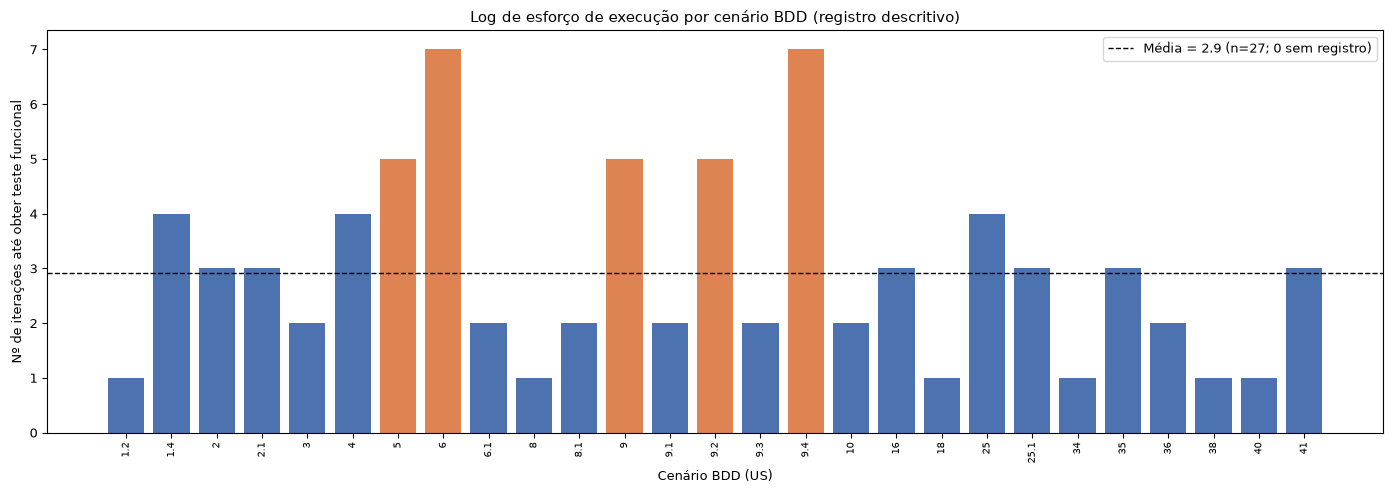

Maiores esforços registrados: [{'US': '6', 'Iteracoes': 7.0}, {'US': '9.4', 'Iteracoes': 7.0}, {'US': '5', 'Iteracoes': 5.0}]


In [10]:
df_plot = df_validos.sort_values('US', key=lambda col: col.map(us_sort_key)).reset_index(drop=True)
tem_registro = df_plot['Iteracoes'].notna()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_plot))
cores = np.where(~tem_registro, '#CCCCCC', np.where(df_plot['Iteracoes'].fillna(0) >= 5, '#DD8452', '#4C72B0'))
ax.bar(x, df_plot['Iteracoes'].fillna(0), color=cores)
for xi, sem_reg in zip(x, ~tem_registro):
    if sem_reg:
        ax.text(xi, 0.15, 'N/D', ha='center', va='bottom', fontsize=6, rotation=90)

media_iter = df_plot.loc[tem_registro, 'Iteracoes'].mean()
ax.axhline(media_iter, color='black', linestyle='--', linewidth=1,
           label=f'Média = {media_iter:.1f} (n={tem_registro.sum()}; {(~tem_registro).sum()} sem registro)')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['US'], rotation=90, fontsize=7)
ax.set_xlabel('Cenário BDD (US)')
ax.set_ylabel('Nº de iterações até obter teste funcional')
ax.set_title('Log de esforço de execução por cenário BDD (registro descritivo)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebook_chart_iteracoes_execucao.png'), dpi=150)
plt.show()

print(f"Maiores esforços registrados: {df_plot.nlargest(3, 'Iteracoes')[['US', 'Iteracoes']].to_dict('records')}")

### As Iterações desta execução se relacionam com as tentativas reais da Tabela 4?

A célula abaixo carrega a **Tabela 4** (`dados_geracao_testes.xlsx`, a mesma fonte usada na Seção 6) e compara, US a US, o valor de **Iterações** registrado aqui com o **número real de tentativas** (S/N) observado na validação final.

In [11]:
# Carrega a Tabela 4 (execução definitiva, dados_geracao_testes.xlsx) apenas para comparar contagem de tentativas por US
wb_v3_cmp = openpyxl.load_workbook(PATH_DADOS, data_only=True)
ws_v3_cmp = wb_v3_cmp.worksheets[0]
rows_v3_cmp = list(ws_v3_cmp.iter_rows(min_row=1, values_only=True))
exec_idx_cmp = next(i for i, r in enumerate(rows_v3_cmp) if r[0] == 'Execution')

tentativas_v3 = {}
for r in rows_v3_cmp[exec_idx_cmp + 1:]:
    if r[1] is None:
        continue
    us_v3 = decode_us(r[1])
    tentativas_v3.setdefault(us_v3, []).append(r[0])

comparacao = []
for _, row in df_validos.iterrows():
    us_c = row['US']
    if us_c in tentativas_v3:
        seq = tentativas_v3[us_c]
        n_tentativas = sum(1 for x in seq if x in ('S', 'N'))
        comparacao.append({
            'US': us_c,
            'Iterações (snapshot, Seção 4)': row['Iteracoes'],
            'Tentativas reais (Tabela 4, Seção 6)': n_tentativas,
            'Sequência na Tabela 4': '-'.join(x for x in seq if x is not None),
        })

df_comparacao = pd.DataFrame(comparacao).sort_values('US', key=lambda c: c.map(us_sort_key)).reset_index(drop=True)
display(df_comparacao)

,US,"Iterações (snapshot, Seção 4)","Tentativas reais (Tabela 4, Seção 6)",Sequência na Tabela 4
0,1.2,1.0,2,N-S
1,1.4,4.0,1,S
2,2,3.0,1,S
3,2.1,3.0,1,S
4,3,2.0,1,S
5,4,4.0,3,N-N-S
6,5,5.0,3,N-N-S
7,6,7.0,6,N-N-N-N-N-S
8,6.1,2.0,1,S
9,8,1.0,1,S


Com a Tabela 3 e a Tabela 4 vindas da mesma planilha (`dados_geracao_testes.xlsx`), a correspondência entre as duas medições evidenciou as diferenças são pequenas (0 a 2). Ainda assim, os números **não são idênticos**, o que é esperado: "Iterações" conta o esforço total percebido pelos autores durante a fase de calibração (inclui pequenos ajustes que não necessariamente geraram uma nova tentativa de execução completa), enquanto a Tabela 4 conta apenas execuções de ponta a ponta com resultado S/N. Os casos mais discrepantes são US9 (5 iterações registradas contra apenas 1 tentativa real) e US9.4 (7 contra 2), enquanto em apenas 3 casos (US1.2, US34, US40) a Tabela 4 exigiu mais tentativas do que o número de Iterações sugeria.

Com isso, a Tabela 4 (Seção 6) será a tabela usada para responder a QE-1, por ser a única com registro objetivo de sucesso/falha tentativa a tentativa.

---

## 5 - Obstáculos e Registros da Execução

Durante a execução, foram registrados os seguintes obstáculos (fonte: relato dos autores + planilhas de acompanhamento):

- **4 USs bloqueadas por bugs reais confirmados no próprio CAPJu** (US7, US28, US37, US39): em cada uma, os autores testaram ao vivo e confirmaram que a funcionalidade não se comporta como o critério de aceite exige (ex.: US39, vazamento de dados entre unidades organizacionais; US7, o backend não guarda o histórico de datas por etapa do processo). Nesses casos, o processo de escrever o cenário BDD chegou a expor o comportamento incorreto da aplicação, impedindo até a elaboração de um cenário testável.

- **6 USs bloqueadas por critério de aceite ambíguo ou não especificado** (US1, US1.1, US1.3, US19, US19.1, US19.2): o texto do critério de aceite menciona uma "padronização" (de ações, alertas ou títulos) sem nunca definir, em nenhum documento, qual é essa padronização. Diferente do caso anterior, aqui a limitação não está na aplicação nem na IA, e sim na especificação de origem, que não é testável como está escrita.

- O *system prompt* dificilmente acerta de primeira. O pior caso encontrado (US06) precisou de 5 tentativas com falha antes de gerar um teste automatizado funcional (6 tentativas no total). Para a maioria das USs executadas, de 1 a 3 tentativas foram suficientes.

> Cada ajuste feito durante a execução (troca de seletor, reescrita de trecho do BDD, preparação de dado de teste, etc.) foi registrado em texto livre na coluna "Observações" da planilha.

---

## Síntese da Execução

| Item | Resultado |
|---|---|
| USs levantadas no planejamento (TCC1) | 23 |
| USs base presentes na Tabela 3 (todas as planejadas) | 23 |
| Cenários BDD (US + variantes de CA) na execução de calibração (Seção 4) | 37 |
| Cenários bloqueados (sem métricas): bug real confirmado no CAPJu | 4 (US7, US28, US37, US39) |
| Cenários bloqueados (sem métricas): critério de aceite ambíguo/não especificado | 6 (US1, US1.1, US1.3, US19, US19.1, US19.2) |
| Métodos de Passo (M2) sem implementação na execução de calibração | 0 |
| Métodos POM (M4) sem implementação na execução de calibração | 0 |
| Estágios de calibração do *system prompt* | 3 |
| Iterações médias na execução (não comparável à Tabela 4) | ~2,9 (min. 1, máx. 7) |

A execução do estudo de caso está documentada de ponta a ponta: da adaptação da ferramenta, passando pela calibração do instrumento (system prompt) em três estágios, até a execução consolidada dos cenários BDD nas 23 Histórias de Usuário do CAPJu, com os obstáculos reais encontrados no caminho.

A partir daqui, o notebook avança para a **Análise de Dados**: a resposta à Questão Específica 1 (QE-1), construída a partir da Tabela 4 (execução definitiva), a única fonte que registra, tentativa a tentativa, se o teste gerado de fato passou ao rodar contra a aplicação real.

---

## 6 - Análise de Dados: Resultados da Questão Específica 1 (QE-1)

> **Nota de escopo dos dados:** toda a análise desta seção usa exclusivamente a **Tabela 4 (Execução Final)**, sendo a única tabela em que cada linha representa uma tentativa real de execução, com resultado verificado (`Execution`: S/N, ou em branco para os cenários bloqueados por bug/critério ambíguo, ver Seção 4). As Tabelas 1-3 (fase de calibração do *system prompt*, Seção 2) não entram nesta análise, por representarem uma etapa exploratória do instrumento, e não uma medição de resultado.

**QE-1:** *"Em que medida a forma de escrita dos cenários BDD influencia a eficácia e a qualidade do código de testes automatizados gerado por IA no contexto do CAPJu?"*

**Resposta:** colocando dentro do BDD os IDs necessários, os textos que devem ser validados, e `[N]` entre colchetes para os casos em que um elemento aparecesse mais de uma vez, acompanhado de um *system prompt* que ensinasse a IA a interpretar essas convenções e gerar o código corretamente para cada BDD.

Um achado lateral relevante: o CAPJu representa um caso típico de aplicação que foi desenvolvida sem pensar em testes automatizados, o que é perceptível pela falta de IDs em elementos-chave da interface. Isso teve que ser contornado com o uso extensivo de **seletores CSS**, que funcionam como um "endereço" apontando para um local específico da página HTML, quando não há um ID estável disponível.

In [12]:
# Carrega a Tabela 4 (Execução Final) a partir da planilha dados_geracao_testes.xlsx
wb_v3 = openpyxl.load_workbook(PATH_DADOS, data_only=True)
ws_v3 = wb_v3.worksheets[0]
rows_v3 = list(ws_v3.iter_rows(min_row=1, values_only=True))

# A Tabela 4 começa na linha em que a coluna A tem o cabeçalho 'Execution'
exec_header_idx = next(i for i, r in enumerate(rows_v3) if r[0] == 'Execution')

tentativas = []
for r in rows_v3[exec_header_idx + 1:]:
    if r[1] is None:  # sem US associada -> fim da tabela
        continue
    tentativas.append({
        'execution': r[0],
        'us': decode_us(r[1]),
        'm1_step_gerados': to_num(r[7]),
        'm3_pom_gerados': to_num(r[8]),
        'm2_step_sem_impl': to_num(r[11]),
        'm4_pom_sem_impl': to_num(r[12]),
        'observacao': r[17] if isinstance(r[17], str) else None,
    })

df_v3 = pd.DataFrame(tentativas)

# Cenarios bloqueados (bug real ou criterio de aceite ambiguo, ver Secao 4) nao tem Execution S/N -> excluidos da analise
df_validas = df_v3[df_v3['execution'].isin(['S', 'N'])].copy()

m1_total = df_validas['m1_step_gerados'].sum()
m3_total = df_validas['m3_pom_gerados'].sum()
m2_total = df_validas['m2_step_sem_impl'].sum()
m4_total = df_validas['m4_pom_sem_impl'].sum()

print(f'Tentativas registradas na Tabela 4: {len(df_v3)}  (das quais bloqueadas/sem Execution: {df_v3["execution"].isna().sum()})')
print(f'Tentativas válidas (S ou N) usadas na análise: {len(df_validas)}')
print()
print(f'M1 - Total de métodos de Step Definition gerados: {m1_total:.0f}')
print(f'M3 - Total de métodos de POM gerados: {m3_total:.0f}')
print(f'M2 - Métodos de Step Definition SEM implementação: {m2_total:.0f}')
print(f'M4 - Métodos de POM SEM implementação: {m4_total:.0f}')

Tentativas registradas na Tabela 4: 64  (das quais bloqueadas/sem Execution: 10)
Tentativas válidas (S ou N) usadas na análise: 54

M1 - Total de métodos de Step Definition gerados: 546
M3 - Total de métodos de POM gerados: 428
M2 - Métodos de Step Definition SEM implementação: 0
M4 - Métodos de POM SEM implementação: 0


### Eficácia: sempre 100%, mesmo antes da Tabela 4

Mesmo nas primeiras tentativas, ainda na fase de construção do *system prompt* (Tabelas 1-3), as Métricas 1 a 8 (completude estrutural do código) sempre bateram 100%. Considerando apenas a Tabela 4 (a única utilizada nesta análise de resultados), foram gerados **546 métodos de Step Definition** (Métrica 1.1) e **428 métodos de Page Object** (Métrica 1.3), sendo que **nenhum método, em nenhuma das duas categorias, ficou sem implementação** (Métricas 1.2 e 1.4 = 0), confirmado pela célula acima.

Isso está ligado à primeira parte de QE-1, sobre **eficácia** (completude estrutural do código): ela não varia com a forma de escrita do BDD, porque o desenho do estudo e a própria Inteligência Artificial sempre produzem código estruturalmente completo, independentemente de o seletor estar ou não correto. Portanto, não há variação a ser explicada por essa métrica. Isso não significa que a escrita do BDD não importa, e sim que essa métrica específica não é sensível a esse tipo de problema.

### Qualidade: a Métrica 1.9 é onde a variação real é evidenciada

A segunda parte de QE-1 aborda a **qualidade do código gerado**. A coluna *Execution* da Tabela 4 registra o resultado de cada tentativa de execução do teste no Cypress, distinguindo execuções bem-sucedidas (S) de execuções com falha (N). Esses registros são utilizados baseando-se da Métrica 1.9 de Nettur et al. (2025), que avalia a ocorrência de erros de sintaxe e de execução no código gerado. Nesse caso, além de verificar a completude estrutural do código, a análise considera seu comportamento quando efetivamente executado contra a aplicação CAPJu.

In [13]:
# Estatísticas de execução real (Métrica 1.9): sucesso (S) vs. falha (N) por tentativa
contagem_exec = df_validas['execution'].value_counts()
total_tentativas = len(df_validas)
total_sucesso = contagem_exec.get('S', 0)
total_falha = contagem_exec.get('N', 0)

# Nº de tentativas por US (para achar quem passou de primeira e o pior caso)
tentativas_por_us = df_validas.groupby('us').size().sort_values(ascending=False)
us_primeira_tentativa = (tentativas_por_us == 1).sum()
total_us_ativas = tentativas_por_us.shape[0]
pior_us = tentativas_por_us.idxmax()
pior_us_tentativas = tentativas_por_us.max()

print(f'Total de tentativas (S + N): {total_tentativas}')
print(f'Sucessos (S): {total_sucesso}   |   Falhas (N): {total_falha}')
print()
print(f'USs ativas (com ao menos 1 tentativa real): {total_us_ativas}')
print(f'USs que passaram já na 1ª tentativa: {us_primeira_tentativa} de {total_us_ativas} ({us_primeira_tentativa/total_us_ativas:.1%})')
print(f'Pior caso: US {pior_us}, com {pior_us_tentativas} tentativas (= {pior_us_tentativas - 1} falhas até o sucesso)')

Total de tentativas (S + N): 54
Sucessos (S): 27   |   Falhas (N): 27

USs ativas (com ao menos 1 tentativa real): 27
USs que passaram já na 1ª tentativa: 12 de 27 (44.4%)
Pior caso: US 6, com 6 tentativas (= 5 falhas até o sucesso)


Aqui há variação real: na Tabela 4, foram feitas 54 tentativas, das quais 27 tiveram sucesso e 27 falharam. Doze das 27 USs passaram já na primeira tentativa (44,4%), enquanto a US 6 precisou de 5 falhas antes de conseguir executar, o pior caso do estudo. Como será detalhado adiante, a maioria das falhas de execução acontece porque a IA não consegue identificar corretamente o elemento de interface, que é exatamente o problema que este estudo tenta caracterizar.

O gráfico abaixo mostra o número de tentativas até o sucesso, US a US (equivalente a `nº de falhas + 1`, já que a última tentativa de cada US ativa é sempre um sucesso).

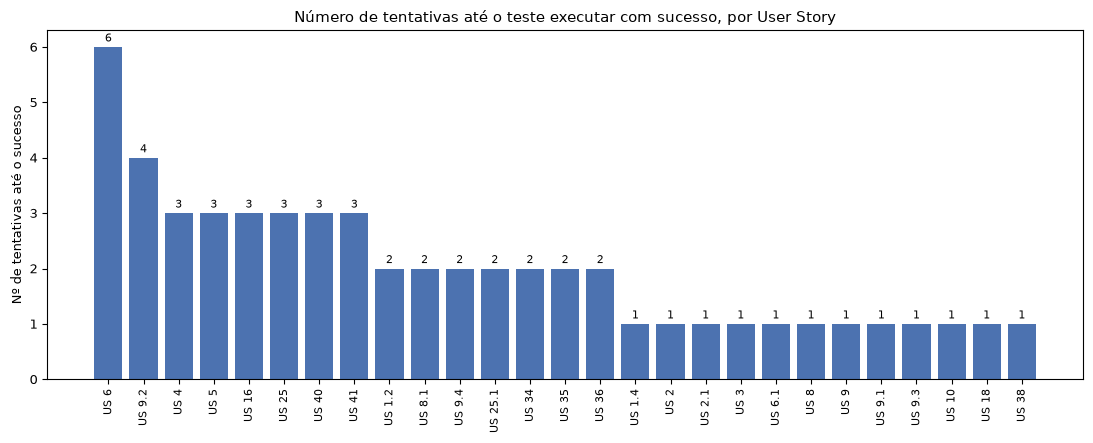

In [14]:
# Gráfico 1: número de tentativas até o teste executar com sucesso, por User Story
# (ordenado da US com mais tentativas para a com menos; empates desempatados pela ordem natural da US)
ordem = sorted(tentativas_por_us.index, key=lambda u: (-tentativas_por_us[u], us_sort_key(u)))
valores = [tentativas_por_us[u] for u in ordem]

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar([f'US {u}' for u in ordem], valores, color='#4C72B0')
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, str(int(v)), ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Nº de tentativas até o sucesso')
ax.set_title('Número de tentativas até o teste executar com sucesso, por User Story')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebook_chart_tentativas_por_us_v3.png'), dpi=150)
plt.show()

### Enquadramento teórico: (ISO/IEC 25010)

De acordo com a ISO/IEC 25010, testabilidade é o *"grau de efetividade e eficiência com que critérios de teste podem ser estabelecidos para um sistema, produto ou componente, e com que os testes podem ser realizados para determinar se esses critérios foram atendidos"*.

Essa definição já separa exatamente os dois eixos que os dados confirmam:

- **Completude da Geração** (M1-M8) → sempre 100% → **não varia** com a forma de escrita do BDD.
- **Execução / Esforço de Correção** (nº de tentativas / taxa de sucesso por tentativa, M1.9) → **varia muito** (de 1 a 6 tentativas) → e é justamente aqui que a forma como o BDD é escrito mostra influência.

Ou seja: a escrita do BDD não determina **se** a IA consegue gerar código, mas determina **quanto esforço de correção** é necessário até esse código funcionar de fato contra a aplicação real. Como a próxima análise mostra, a maior parte desse esforço está relacionada a como os elementos de interface foram especificados.

### Por que as 27 tentativas falharam?

Para caracterizar melhor essas 27 falhas, cada uma foi analisada individualmente com base na coluna `Observações` registrada no momento da execução, que nesta versão da planilha traz a mensagem de erro real do Cypress para cada tentativa que falhou (ex.: qual seletor não foi encontrado, quantos elementos um seletor casou, qual asserção não bateu). O resultado é uma classificação qualitativa em 8 categorias, com a contagem final abaixo verificada de modo que soma exatamente 27.

,Categoria,Descrição,Ocorrências,%
0,Seletor dinâmico instável,ID/classe auto-gerado pelo React/Chakra/Emotion não corresponde ao DOM real,9,33.3
1,Seletor genérico/ambíguo,Seletor casa com múltiplos elementos na tela (cy.click() rejeita),6,22.2
2,Erro de geração de código,"Texto do step diverge entre .feature e step definition, ou definições duplicadas",6,22.2
3,Elemento repetido sem indexação,"Elemento duplicado na tela, sem [N]/eq(N) de desambiguação",2,7.4
4,BDD descreve comportamento incorreto,Texto/condição esperada nunca ocorre de fato na aplicação,1,3.7
5,Erro de digitação no texto gerado,"Typo alterou a string esperada na asserção (""Process"" em vez de ""Processo"")",1,3.7
6,Lógica de asserção de texto,Esperava string concatenada; DOM tem parágrafos separados,1,3.7
7,Variabilidade pura do modelo,BDD idêntico; nova tentativa interpretou corretamente sozinha,1,3.7


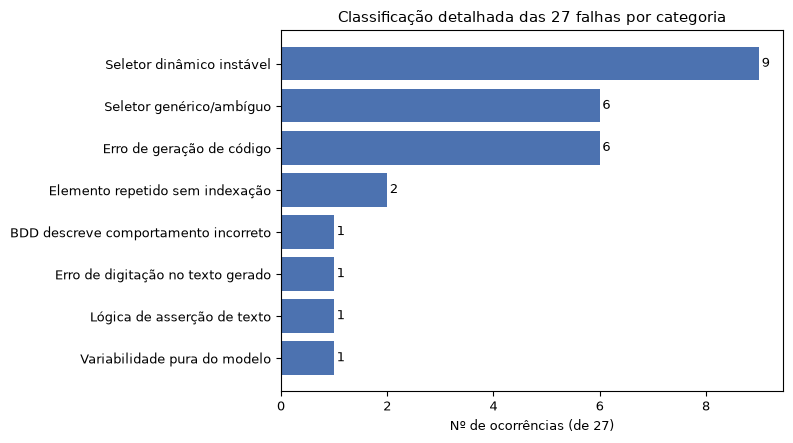

In [15]:
# Classificação qualitativa das 27 falhas reais (Métrica 1.9 = N), por categoria de causa
# Fonte: leitura da mensagem de erro do Cypress registrada na coluna "Observações" de cada tentativa que falhou.
classificacao = pd.DataFrame([
    ('Seletor dinâmico instável', 'ID/classe auto-gerado pelo React/Chakra/Emotion não corresponde ao DOM real', 9),
    ('Seletor genérico/ambíguo', 'Seletor casa com múltiplos elementos na tela (cy.click() rejeita)', 6),
    ('Erro de geração de código', 'Texto do step diverge entre .feature e step definition, ou definições duplicadas', 6),
    ('Elemento repetido sem indexação', 'Elemento duplicado na tela, sem [N]/eq(N) de desambiguação', 2),
    ('BDD descreve comportamento incorreto', 'Texto/condição esperada nunca ocorre de fato na aplicação', 1),
    ('Erro de digitação no texto gerado', 'Typo alterou a string esperada na asserção ("Process" em vez de "Processo")', 1),
    ('Lógica de asserção de texto', 'Esperava string concatenada; DOM tem parágrafos separados', 1),
    ('Variabilidade pura do modelo', 'BDD idêntico; nova tentativa interpretou corretamente sozinha', 1),
], columns=['Categoria', 'Descrição', 'Ocorrências'])
classificacao['%'] = (classificacao['Ocorrências'] / classificacao['Ocorrências'].sum() * 100).round(1)

assert classificacao['Ocorrências'].sum() == total_falha, 'Soma das categorias deve bater com o total de falhas (N)'
display(classificacao)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(classificacao['Categoria'][::-1], classificacao['Ocorrências'][::-1], color='#4C72B0')
for i, v in enumerate(classificacao['Ocorrências'][::-1]):
    ax.text(v + 0.05, i, str(int(v)), va='center', fontsize=9)
ax.set_xlabel(f'Nº de ocorrências (de {total_falha})')
ax.set_title(f'Classificação detalhada das {total_falha} falhas por categoria')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebook_chart_classificacao_falhas_v3.png'), dpi=150)
plt.show()

Agrupando essas oito categorias em quatro grupos de causa raiz, chega-se ao indicador final:

,N,% das 27 falhas
Grupo,,
Relacionado a elemento de interface,17,63.0
Erro de geração de código (não é sobre elemento),6,22.2
Lógica/BDD não corresponde ao app real,3,11.1
Variabilidade pura do modelo (BDD idêntico),1,3.7


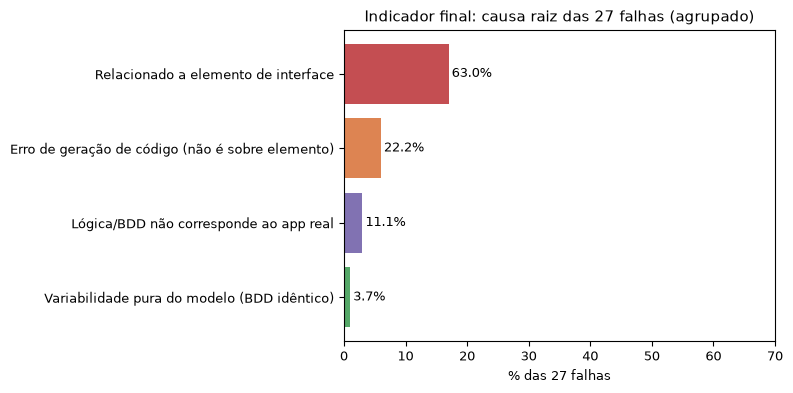

In [16]:
# Indicador final: agrupamento das 8 categorias em 4 grupos de causa raiz
grupo_por_categoria = {
    'Seletor dinâmico instável': 'Relacionado a elemento de interface',
    'Seletor genérico/ambíguo': 'Relacionado a elemento de interface',
    'Elemento repetido sem indexação': 'Relacionado a elemento de interface',
    'Erro de geração de código': 'Erro de geração de código (não é sobre elemento)',
    'Erro de digitação no texto gerado': 'Lógica/BDD não corresponde ao app real',
    'Lógica de asserção de texto': 'Lógica/BDD não corresponde ao app real',
    'BDD descreve comportamento incorreto': 'Lógica/BDD não corresponde ao app real',
    'Variabilidade pura do modelo': 'Variabilidade pura do modelo (BDD idêntico)',
}
classificacao['Grupo'] = classificacao['Categoria'].map(grupo_por_categoria)
indicador = classificacao.groupby('Grupo')['Ocorrências'].sum().sort_values(ascending=False)
indicador_pct = (indicador / indicador.sum() * 100).round(1)

assert indicador.sum() == total_falha
tabela_indicador = pd.DataFrame({'N': indicador, f'% das {total_falha} falhas': indicador_pct})
display(tabela_indicador)

cores_grupo = {'Relacionado a elemento de interface': '#C44E52', 'Erro de geração de código (não é sobre elemento)': '#DD8452',
               'Lógica/BDD não corresponde ao app real': '#8172B2', 'Variabilidade pura do modelo (BDD idêntico)': '#55A868'}
fig, ax = plt.subplots(figsize=(8, 4))
ordem_grupos = indicador.index[::-1]
ax.barh(ordem_grupos, indicador[ordem_grupos], color=[cores_grupo[g] for g in ordem_grupos])
for i, g in enumerate(ordem_grupos):
    ax.text(indicador[g] + 0.5, i, f'{indicador_pct[g]:.1f}%', va='center', fontsize=9)
ax.set_xlabel(f'% das {total_falha} falhas')
ax.set_xlim(0, 70)
ax.set_title(f'Indicador final: causa raiz das {total_falha} falhas (agrupado)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebook_chart_indicador_final_v3.png'), dpi=150)
plt.show()

Esse indicador confirma numericamente a afirmação feita anteriormente: **63,0% das falhas, a maioria absoluta, estão diretamente relacionadas a como o elemento de interface foi referenciado no BDD** (seletor genérico, seletor dinâmico instável, ou elemento repetido sem índice). Isso reforça que a forma de escrita do BDD não determina se a IA consegue gerar código, mas determina o quanto de esforço de correção é necessário até que esse código funcione de fato contra a aplicação real, e que a maior parte desse esforço está concentrada exatamente na forma como os elementos de interface são especificados nos cenários.

**Dois casos ilustram a imprevisibilidade da IA, mesmo com o *system prompt* definitivo:**

- **US 6**: o cenário BDD não mudou nas primeiras 4 tentativas. A 1ª falhou por "Step implementation missing" (o texto do step estava sem aspas no arquivo de feature, mas com aspas no arquivo de step gerado); as 3 seguintes falharam com o mesmo erro de "Multiple matching step definitions", porque duas *step definitions* com a mesma assinatura foram geradas. Só na 5ª tentativa as aspas duplas em torno de "Fluxo Unidade 1" e "Em andamento" foram removidas do texto do BDD, resolvendo a ambiguidade. Isso mostra que qualquer pequena alteração de notação pode gerar erros mesmo com um *system prompt* robusto: nunca sabemos com certeza o que a IA vai gerar.

- **US 25**: o cenário BDD ficou **idêntico** entre a 2ª tentativa (que falhou) e a 3ª (que passou). A 1ª tentativa falhou por não encontrar o ID dinâmico esperado (`#tabs-:r17:--tab-5`); corrigido esse ponto, a 2ª tentativa ainda falhou porque o Cypress encontrou o elemento, mas o modelo não havia interpretado corretamente que o step *"Then the columns Ações, Servidor, Diretor, Administrador should appear"* descrevia quatro colunas distintas a serem verificadas separadamente. Na tentativa seguinte, **sem nenhuma mudança no BDD**, o Cypress Copilot passou a interpretar corretamente essa mesma instrução. Esse caso evidencia a natureza de caixa-preta e a variabilidade inerente ao LLM: mesmo mantendo o BDD e o *system prompt* fixos, o resultado pode variar entre execuções.

---

## 7 - Resposta à Questão de Pesquisa Principal

**Questão principal:** *"De que maneira as especificações BDD devem ser escritas e detalhadas para que sistemas baseados em IA consigam identificar, de forma autônoma, os elementos de interface gráfica necessários para criar testes de sistema automatizados?"*

As especificações BDD devem identificar os elementos de interface com **seletores estáveis e únicos**, priorizando atributos semânticos (`name`, `id`, `aria-label`) ou combinações de atributos que garantam unicidade (ex.: `data-index`). Devem evitar duas práticas que concentraram 63% das falhas observadas:

- Seletores genéricos que correspondem a múltiplos elementos sem indicar um índice.
- Seletores baseados em identificadores dinâmicos gerados automaticamente pelo framework front-end (ex.: hashes do React, Chakra UI ou Emotion), que podem não corresponder ao DOM real durante a execução do teste, e podem inclusive mudar a cada carregamento de página.

Mesmo seguindo essas boas práticas, ainda existe uma parcela residual de falhas: 22% por erros na geração do código (divergência entre o texto do step e a *step definition*, ou definições duplicadas) e 11% por casos em que a lógica do BDD não correspondeu ao comportamento real da aplicação (erro de digitação no texto gerado, asserção mal formulada, ou condição que nunca ocorre na tela), além de uma pequena fração (4%) atribuível à variabilidade pura do próprio modelo, quando uma nova tentativa teve sucesso sem qualquer mudança no BDD. Esses fatores não estão sob controle exclusivo de quem escreve o cenário BDD.

---

## 8 - Limitações

1. **Ausência de garantia de sucesso na primeira execução** *(ameaça à confiabilidade)*: a variabilidade do LLM faz com que, mesmo diante de um BDD correto e IDs precisos, o teste gerado possa não executar de primeira. O caso da US 25 (Seção 6) ilustra isso: o mesmo BDD e o mesmo *system prompt* produziram resultados diferentes em tentativas sucessivas.

2. **Conflito entre *step definitions* duplicadas** *(ameaça à validade de constructo)*: quando dois ou mais cenários BDD compartilham uma linha de step idêntica, o *preprocessor* do Cucumber não consegue determinar qual definição usar durante a execução, gerando um erro de múltiplas correspondências. A solução ideal seria reaproveitar um step comum entre os cenários, mas a ferramenta processa cada BDD de forma independente, sem visibilidade sobre os steps já gerados para outros cenários, portanto não é capaz de fazer essa deduplicação.

3. **Dependência do identificador exato do elemento** *(ameaça à validade interna)*: o BDD precisa fornecer o ID ou seletor exato do elemento de interface; qualquer imprecisão causa erro no teste gerado. Isso vale tanto para IDs quanto para seletores CSS usados como alternativa. A solução aceita seletores CSS, mas exige que sejam igualmente exatos.

4. **Dependência de uma aplicação já preparada para automação** *(ameaça à validade externa)*: o CAPJu não foi desenvolvido pensando em testes automatizados, faltando IDs em elementos-chave, o que obrigou o uso extensivo de seletores CSS complexos como alternativa. Os resultados deste estudo podem não se repetir em aplicações que já nascem com identificadores estáveis, nem em aplicações legadas com estrutura de interface muito diferente da testada aqui.

5. **Uso de um único modelo de linguagem** *(ameaça à validade externa)*: a avaliação foi conduzida exclusivamente com o GPT-4o. Não foi testado se os padrões de erro observados, em especial a concentração em problemas de seletor, se mantêm com outros modelos.

6. **Critérios de Aceitação ambíguos impedem a própria escrita do BDD** *(ameaça à validade de constructo)*: em 6 dos 37 cenários BDD planejados (US1, US1.1, US1.3, US19, US19.1, US19.2), o critério de aceite menciona uma "padronização" sem defini-la em nenhum documento, tornando impossível escrever um cenário BDD testável. Isso é uma limitação anterior à própria IA: nenhuma forma de escrita de BDD resolve um requisito que não especifica o comportamento esperado.

---

## 9 - Trabalhos Futuros

1. **Outros modelos de linguagem**: testar a abordagem com LLMs além do GPT-4o, verificando se os padrões de erro observados (especialmente os relacionados a seletores) se repetem ou variam entre diferentes modelos.

2. **Estruturas alternativas de *system prompt***: testar formatos alternativos (ex.: explicação conceitual ou instruções passo a passo), em contraste com a abordagem de regras explícitas empregada neste trabalho, avaliando se alguma reduz a variabilidade do modelo ou a taxa de erros relacionados a elementos de interface.

3. **Geração em lote por User Story**: testar a geração de testes a partir de um conjunto de cenários BDD de uma só vez (todos os critérios de aceite de uma mesma US em uma única chamada), em vez de um BDD por vez como feito neste estudo. Essa abordagem poderia reduzir o tempo total de geração e mitigar o problema de *step definitions* duplicadas (Limitação 2), já que o modelo passaria a ter visibilidade de todos os steps da US simultaneamente, em vez de processá-los de forma isolada.